# Camada Ouro — Modelo 1: Segmentação de Clientes

> **Dependência:** este notebook lê a saída do `01_Camada_Ouro_EDA.ipynb`.
> **Input:** `ouro/df_cluster.parquet` — features selecionadas por cliente, prontas para clustering.
> **Output:** `ouro/df_cliente_clusterizado.parquet` — df_cluster com coluna `cluster` e `nome_cluster`.

---

## Objetivo

Segmentar os clientes da ClickBus em perfis de comportamento de compra distintos, usando o algoritmo **K-Means** sobre as features de RFM construídas na camada de EDA.

**Pergunta de negócio:** existem grupos de viajantes com padrões de compra suficientemente distintos para justificar estratégias de Growth diferenciadas — campanhas, promoções, timing de comunicação?

**Por que K-Means?**
K-Means minimiza a soma das distâncias quadráticas intra-cluster (inércia). É equivalente a encontrar grupos que minimizam a variância interna — ou seja, clientes dentro do mesmo cluster são mais parecidos entre si do que com clientes de outros clusters. Para features contínuas de RFM em escala normalizada, é a escolha padrão e interpretável.

**Pipeline deste notebook:**
1. Pré-processamento final (padronização com `StandardScaler`)
2. Escolha do K ideal (Elbow + Silhouette Score)
3. Ajuste do modelo final e geração dos clusters
4. Interpretação econômica dos perfis
5. Visualização em PCA 2D
6. Análise de composição por período COVID

In [20]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

!git clone https://github.com/vsmacedo-datafinance/Challenge_ClickBus_FIAP_2025.git 2>/dev/null

sys.path.append('/content/Challenge_ClickBus_FIAP_2025')

drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DRIVE_BASE = "/content/drive/MyDrive/Portifólio DS Vini/Challenge_ClickBus_2025/data"

df_cliente = pd.read_parquet(f"{DRIVE_BASE}/ouro/df_cliente.parquet")
df_cluster = pd.read_parquet(f"{DRIVE_BASE}/ouro/df_cluster.parquet")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df_cluster.shape

(462800, 12)

In [3]:
df_cluster.head()

,id_cliente,gmv_total_log,total_compras_log,recencia_dias_log,tempo_vida_dias_log,n_destinos_distintos_log,pop_trecho_media_log,score_fidelidade,prop_fim_semana,prop_feriado,tickets_medio,prop_ida_volta
0,Cliente_0,4.522006,0.693147,6.563856,0.000000,0.693147,9.425532,1.000000,1.0,0.0,1.0,0.0
1,Cliente_1,5.093750,1.098612,5.429346,6.190315,1.098612,8.167778,0.509136,0.5,0.0,1.0,0.0
2,Cliente_10000,5.362090,1.098612,6.622736,6.987490,1.098612,6.601230,0.572654,0.0,0.0,1.5,0.5
3,Cliente_100000,5.803266,0.693147,4.143135,0.000000,0.693147,4.234107,1.000000,0.0,0.0,2.0,1.0
4,Cliente_100001,4.581287,0.693147,6.329721,0.000000,0.693147,5.220356,1.000000,1.0,0.0,2.0,0.0


In [4]:
df_cluster.describe().T

,count,mean,std,min,25%,50%,75%,max
gmv_total_log,462800.0,5.404339,1.031217,1.646734,4.692906,5.351337,6.073321,12.637439
total_compras_log,462800.0,1.045389,0.550092,0.693147,0.693147,0.693147,1.098612,7.090910
recencia_dias_log,462800.0,6.165183,1.383077,0.000000,5.517453,6.473891,7.185387,8.123558
tempo_vida_dias_log,462800.0,2.041369,2.793291,0.000000,0.000000,0.000000,4.969813,8.113726
n_destinos_distintos_log,462800.0,0.896503,0.314728,0.693147,0.693147,0.693147,1.098612,4.718499
pop_trecho_media_log,462800.0,6.232669,2.097146,0.693147,4.875197,6.461468,7.655391,10.174278
score_fidelidade,462800.0,0.901000,0.184632,0.078655,0.894948,1.000000,1.000000,1.000000
prop_fim_semana,462800.0,0.261787,0.380996,0.000000,0.000000,0.000000,0.500000,1.000000
prop_feriado,462800.0,0.178651,0.336382,0.000000,0.000000,0.000000,0.200000,1.000000
tickets_medio,462800.0,1.482975,0.840042,1.000000,1.000000,1.000000,2.000000,12.000000


In [5]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462800 entries, 0 to 462799
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                462800 non-null  object 
 1   gmv_total_log             462800 non-null  float64
 2   total_compras_log         462800 non-null  float64
 3   recencia_dias_log         462800 non-null  float64
 4   tempo_vida_dias_log       462800 non-null  float64
 5   n_destinos_distintos_log  462800 non-null  float64
 6   pop_trecho_media_log      462800 non-null  float64
 7   score_fidelidade          462800 non-null  float64
 8   prop_fim_semana           462800 non-null  float64
 9   prop_feriado              462800 non-null  float64
 10  tickets_medio             462800 non-null  float64
 11  prop_ida_volta            462800 non-null  float64
dtypes: float64(11), object(1)
memory usage: 42.4+ MB


**Validação do input:**

`df_cluster` é o dataframe de features construído na EDA — cada linha é um cliente, cada coluna é uma variável de comportamento já tratada (sem nulos, sem redundância, com transformação `log1p` nas variáveis assimétricas).

Antes de modelar, confirmar:
- Sem colunas de data ou string que quebrariam o `StandardScaler`
- Todas as features são numéricas contínuas
- `id_cliente` presente para reidentificar os clusters depois

> O `StandardScaler` na próxima etapa é obrigatório para K-Means. O algoritmo usa distância euclidiana — sem padronização, variáveis em escalas maiores (ex: `gmv_total`) dominariam o cálculo de distância e o clustering refletiria apenas GMV, não o comportamento multidimensional do cliente.

# Pré processamento e Clusterização

In [6]:
X = df_cluster.drop(columns=['id_cliente']).astype('float64')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

| Critério | O que mede | Como usar |
|---|---|---|
| **Elbow (Inércia)** | Compactação intra-cluster | Identificar onde a curva "dobra" — ganho marginal de adicionar +1 cluster começa a cair |
| **Silhouette Score** | Separação entre clusters | Quanto maior, melhor. Compara coesão interna com separação externa. Máximo = 1.0 |

Os dois critérios raramente apontam exatamente para o mesmo K — a decisão final combina o que os gráficos sugerem com o que **faz sentido de negócio**: clusters precisam ser interpretáveis e acionáveis pelo time de Growth.

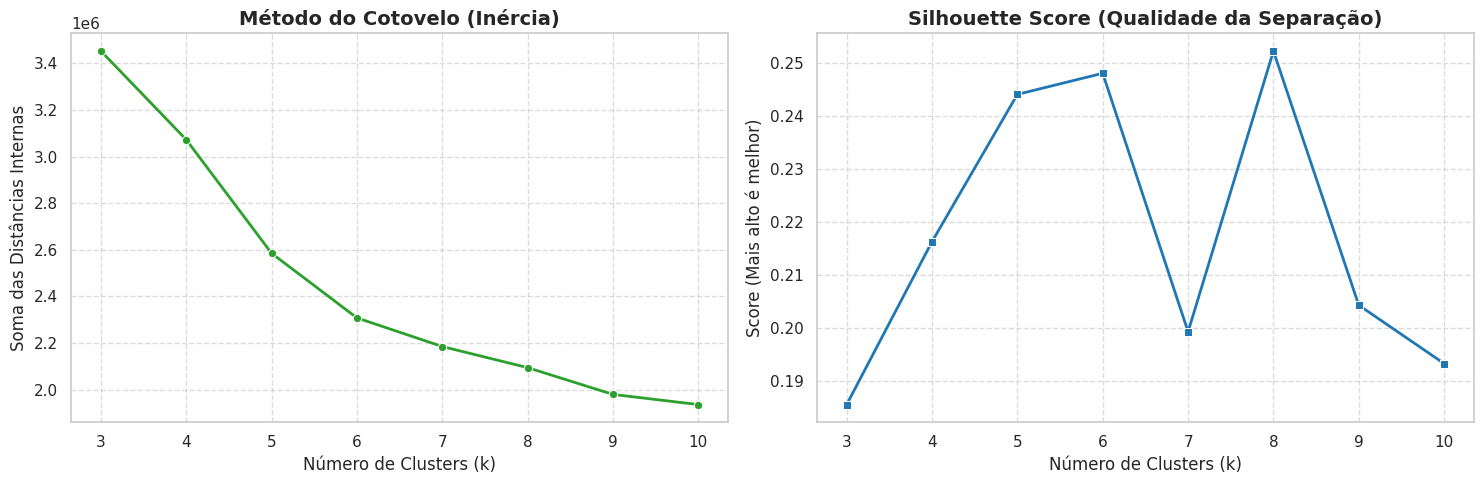

In [7]:
inercia = []
silhouette_scores = []
K_range = range(3, 11) # por regra de negócio, foi deicido começar com 3 clusters, visto que 2 não seria o bastante para seguimentação dos clientes, dado o desafio

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)

    inercia.append(kmeans.inertia_)

    # amostra com 50.000 clientes
    score = silhouette_score(X_scaled, kmeans.labels_, sample_size=50000, random_state=42)
    silhouette_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.lineplot(x=K_range, y=inercia, marker='o', ax=axes[0], color='#2ca02c', linewidth=2)
axes[0].set_title('Método do Cotovelo (Inércia)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Soma das Distâncias Internas')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x=K_range, y=silhouette_scores, marker='s', ax=axes[1], color='#1f77b4', linewidth=2)
axes[1].set_title('Silhouette Score (Qualidade da Separação)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Score (Mais alto é melhor)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Leitura dos gráficos:**

A curva de inércia indica onde o ganho de compactação começa a diminuir — o "cotovelo". O Silhouette Score indica a qualidade de separação entre grupos. A decisão do K ideal considera os dois em conjunto com o critério de interpretabilidade de negócio.

**Trade-off do K:**
- K pequeno (3–4): clusters mais genéricos, mais fáceis de nomear, estratégias de Growth mais amplas
- K grande (7+): clusters mais precisos estatisticamente, mas difíceis de diferenciar em campanha e de explicar para stakeholders

> **Regra prática:** o K ideal para portfólio e para negócio raramente passa de 6. Acima disso, os clusters começam a se sobrepor e as estratégias derivadas convergem.

In [8]:
def resumir_clusters(df_cluster, X_scaled, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)

    df_temp = df_cluster.copy()
    df_temp["cluster"] = labels

    perfil = (
        df_temp
        .groupby("cluster")
        .agg(
            qtd_clientes=("id_cliente", "nunique"),
            gmv_total_log=("gmv_total_log", "median"),
            total_compras_log=("total_compras_log", "median"),
            recencia_dias_log=("recencia_dias_log", "median"),
            tempo_vida_dias_log=("tempo_vida_dias_log", "median"),
            n_destinos_distintos_log=("n_destinos_distintos_log", "median"),
            tickets_medio=("tickets_medio", "mean"),
            score_fidelidade=("score_fidelidade", "mean"),
            prop_fim_semana=("prop_fim_semana", "mean"),
            prop_feriado=("prop_feriado", "mean"),
            prop_ida_volta=("prop_ida_volta", "mean"),
        )
        .round(2)
    )

    total = perfil["qtd_clientes"].sum()
    perfil["%_da_base"] = (perfil["qtd_clientes"] / total * 100).round(1)

    cols = ["qtd_clientes", "%_da_base"] + [c for c in perfil.columns if c not in ["qtd_clientes", "%_da_base"]]
    return perfil[cols]

## Resumo dos Clusters

In [9]:
for k in [4, 5, 6]:
    print(f"\n=== Resumo dos clusters para k = {k} ===")
    display(resumir_clusters(df_cluster, X_scaled, k))


=== Resumo dos clusters para k = 4 ===


,qtd_clientes,%_da_base,gmv_total_log,total_compras_log,recencia_dias_log,tempo_vida_dias_log,n_destinos_distintos_log,tickets_medio,score_fidelidade,prop_fim_semana,prop_feriado,prop_ida_volta
cluster,,,,,,,,,,,,
0,116237,25.1,5.89,1.10,6.16,5.33,1.10,1.43,0.80,0.26,0.16,0.10
1,52176,11.3,6.92,2.08,5.22,6.62,1.39,1.38,0.58,0.26,0.17,0.10
2,238300,51.5,4.94,0.69,6.71,0.00,0.69,1.52,1.00,0.27,0.00,0.13
3,56087,12.1,4.90,0.69,6.66,0.00,0.69,1.52,0.99,0.24,0.98,0.12



=== Resumo dos clusters para k = 5 ===


,qtd_clientes,%_da_base,gmv_total_log,total_compras_log,recencia_dias_log,tempo_vida_dias_log,n_destinos_distintos_log,tickets_medio,score_fidelidade,prop_fim_semana,prop_feriado,prop_ida_volta
cluster,,,,,,,,,,,,
0,111282,24.0,5.88,1.39,6.16,5.36,1.10,1.37,0.80,0.27,0.16,0.07
1,51237,11.1,6.94,2.08,5.20,6.63,1.39,1.39,0.58,0.26,0.17,0.10
2,44140,9.5,5.71,0.69,6.58,0.00,0.69,2.99,0.98,0.19,0.16,0.93
3,49676,10.7,4.82,0.69,6.66,0.00,0.69,1.33,0.99,0.24,0.98,0.00
4,206465,44.6,4.85,0.69,6.73,0.00,0.69,1.28,1.00,0.28,0.00,0.00



=== Resumo dos clusters para k = 6 ===


,qtd_clientes,%_da_base,gmv_total_log,total_compras_log,recencia_dias_log,tempo_vida_dias_log,n_destinos_distintos_log,tickets_medio,score_fidelidade,prop_fim_semana,prop_feriado,prop_ida_volta
cluster,,,,,,,,,,,,
0,109298,23.6,5.89,1.39,6.16,5.40,1.10,1.37,0.79,0.26,0.16,0.07
1,50501,10.9,6.95,2.08,5.19,6.63,1.39,1.39,0.58,0.26,0.17,0.10
2,42720,9.2,5.69,0.69,6.57,0.00,0.69,2.96,0.98,0.19,0.17,0.96
3,48576,10.5,4.82,0.69,6.66,0.00,0.69,1.34,0.99,0.25,0.99,0.00
4,150181,32.5,4.89,0.69,6.81,0.00,0.69,1.30,1.00,0.00,0.00,0.00
5,61524,13.3,4.80,0.69,6.59,0.00,0.69,1.30,0.99,0.97,0.01,0.00


**Critério de decisão para o K final:**

Após analisar os perfis acima, o K=5 foi escolhido porque:

1. **Separação clara em valor:** os clusters se diferenciam bem em `gmv_total_log` e `total_compras_log` — há segmentos de alto e baixo valor distintos.
2. **Comportamento acionável:** `prop_feriado`, `score_fidelidade` e `tickets_medio` apresentam padrões diferentes entre grupos — cada cluster sugere uma estratégia de Growth distinta.
3. **Distribuição equilibrada:** nenhum cluster concentra menos de 5% da base, garantindo massa crítica para campanhas.
4. **K=4 perde granularidade:** agrupava perfis que têm estratégias diferentes (ex: one-shots de feriado vs one-shots regulares). **K=6 fragmenta** um cluster que já é coeso, sem ganho interpretável.

> A escolha do K não é puramente matemática — é uma decisão de negócio. O Silhouette Score orienta, mas o critério final é: *"esse cluster tem um nome e uma estratégia de Growth próprios?"*.

In [27]:
k_final = 5

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
df_cluster["cluster"] = kmeans_final.fit_predict(X_scaled)

perfil_clusters = resumir_clusters(df_cluster, X_scaled, k_final)

In [11]:
from sklearn.decomposition import PCA

# PCA em cima das features já padronizadas
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
df_pca["cluster"] = df_cluster["cluster"].values

print("Variância explicada pelos 2 primeiros componentes:", pca.explained_variance_ratio_.round(3))

Variância explicada pelos 2 primeiros componentes: [0.355 0.153]


## Visualização PCA — Separação Espacial dos Clusters

**O que é PCA aqui:**

PCA (Análise de Componentes Principais) reduz as N features do `df_cluster` para 2 dimensões, preservando ao máximo a variância original. Não é um modelo preditivo — é uma ferramenta de visualização.

**Como ler o gráfico:**
- Pontos do mesmo cluster próximos entre si → o cluster é coeso (K-Means fez um bom trabalho nessa região)
- Clusters bem separados visualmente → há separação real no espaço de features
- Sobreposição entre clusters → esses dois grupos são parecidos — considere se realmente precisam de estratégias diferentes

**A variância retida** indica quanto da informação original foi preservada nas 2 dimensões. Variância < 50% significa que o gráfico captura menos da metade do "espaço" onde os clusters vivem — a separação visual pode subestimar a separação real.

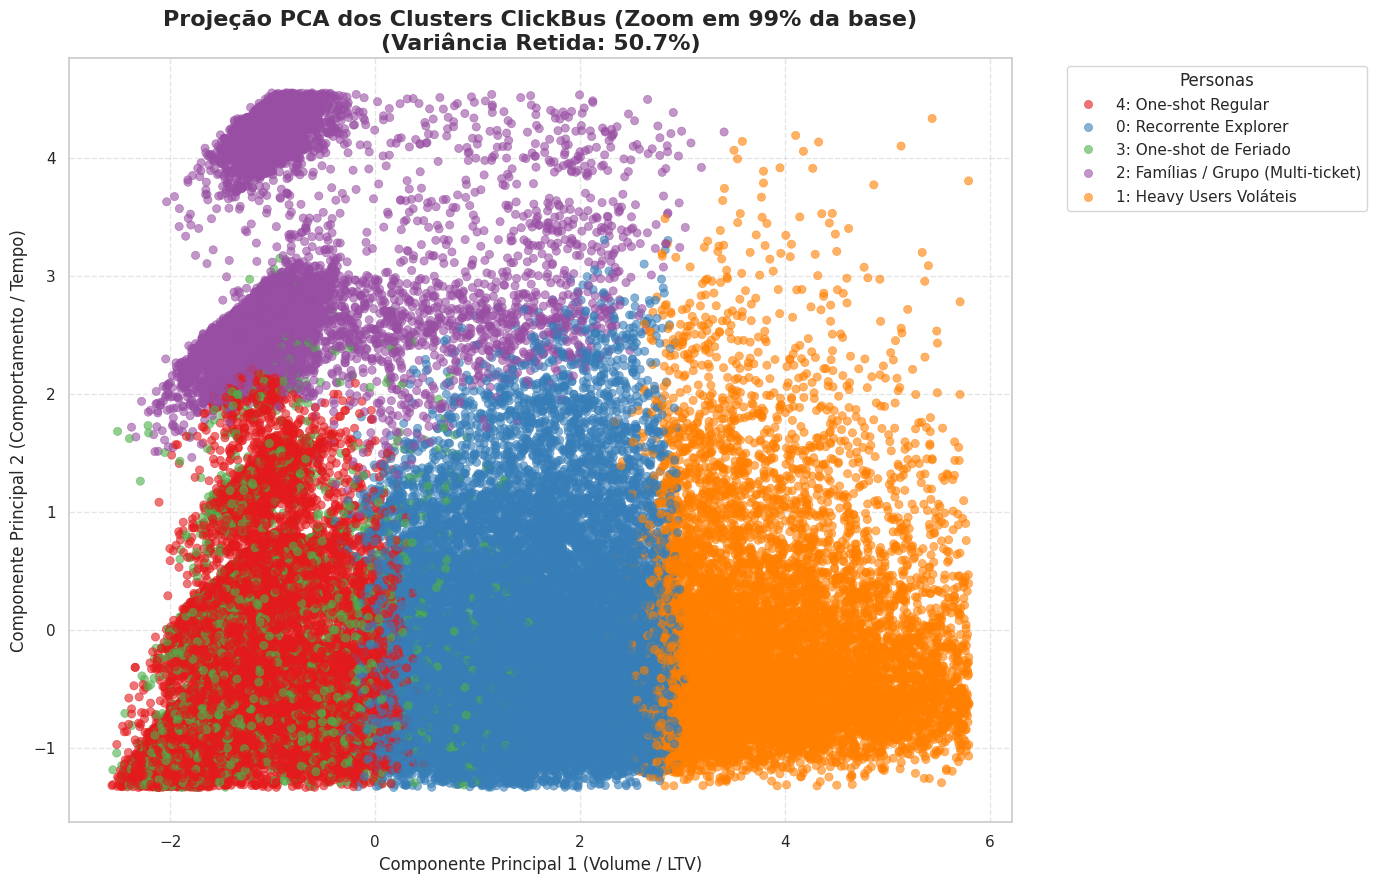

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
variancia_explicada = pca.explained_variance_ratio_.sum() * 100

df_pca = pd.DataFrame(
    X_pca,
    columns=["Componente Principal 1", "Componente Principal 2"]
)
df_pca["Cluster"] = df_cluster["cluster"].values

nomes_clusters = {
    0: "0: Recorrente Explorer",
    1: "1: Heavy Users Voláteis",
    2: "2: Famílias / Grupo (Multi-ticket)",
    3: "3: One-shot de Feriado",
    4: "4: One-shot Regular"
}
df_pca["Nome_Cluster"] = df_pca["Cluster"].map(nomes_clusters)

df_pca_sample = df_pca.sample(n=100000, random_state=42)

# definição de limites para remover outliers visuais
limite_p1_max = df_pca_sample["Componente Principal 1"].quantile(0.99)
limite_p2_max = df_pca_sample["Componente Principal 2"].quantile(0.99)
limite_p2_min = df_pca_sample["Componente Principal 2"].quantile(0.01)

df_pca_zoom = df_pca_sample[
    (df_pca_sample["Componente Principal 1"] <= limite_p1_max) &
    (df_pca_sample["Componente Principal 2"] <= limite_p2_max) &
    (df_pca_sample["Componente Principal 2"] >= limite_p2_min)
]

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_pca_zoom,
    x="Componente Principal 1",
    y="Componente Principal 2",
    hue="Nome_Cluster",
    palette="Set1",
    alpha=0.6,
    s=35,
    edgecolor=None
)

plt.title(
    f"Projeção PCA dos Clusters ClickBus (Zoom em 99% da base)\n"
    f"(Variância Retida: {variancia_explicada:.1f}%)",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Componente Principal 1 (Volume / LTV)", fontsize=12)
plt.ylabel("Componente Principal 2 (Comportamento / Tempo)", fontsize=12)

plt.legend(
    title="Personas",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=11,
    title_fontsize=12
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
features_dna = [
    "gmv_total_log",
    "total_compras_log",
    "tickets_medio",
    "score_fidelidade",
    "prop_feriado",
    "prop_ida_volta",
]

media_global = df_cluster[features_dna].mean()

perfil_clusters = (
    df_cluster
    .groupby("cluster")
    .agg({col: "mean" for col in features_dna})
    .round(2)
)

dna_clusters = perfil_clusters.copy()
for col in features_dna:
    dna_clusters[col] = (dna_clusters[col] / media_global[col]).round(2)

dna_clusters.index = dna_clusters.index.map(nomes_clusters)

mapa_nomes_features = {
    "gmv_total_log": "Índice de Valor (GMV)",
    "total_compras_log": "Índice de Frequência",
    "tickets_medio": "Índice de Tamanho da Compra",
    "score_fidelidade": "Índice de Fidelidade",
    "prop_feriado": "Índice de Foco em Feriados",
    "prop_ida_volta": "Índice de Ida e Volta",
}

dna_tabela = dna_clusters[features_dna].rename(columns=mapa_nomes_features)

display(dna_tabela)

,Índice de Valor (GMV),Índice de Frequência,Índice de Tamanho da Compra,Índice de Fidelidade,Índice de Foco em Feriados,Índice de Ida e Volta
cluster,,,,,,
0: Recorrente Explorer,1.09,1.28,0.92,0.89,0.90,0.59
1: Heavy Users Voláteis,1.29,2.10,0.94,0.64,0.95,0.85
2: Famílias / Grupo (Multi-ticket),1.06,0.74,2.02,1.09,0.90,7.90
3: One-shot de Feriado,0.89,0.73,0.90,1.10,5.49,0.00
4: One-shot Regular,0.89,0.70,0.86,1.11,0.00,0.00


**Leitura da tabela de DNA dos clusters:**

Cada valor na tabela é um **índice relativo à média geral da base** — um valor de 1.5 significa que aquele cluster está 50% acima da média em aquela dimensão. Isso permite comparar clusters de tamanhos muito diferentes numa escala comum.

**Destaques por perfil:**

| Perfil | Diferencial principal | Estratégia de Growth |
|---|---|---|
| **Heavy User Volátil** | Índice de Valor e Frequência >> 1 | Programa de fidelidade — capturar share of wallet; ele já compra, só precisa de motivo para concentrar na ClickBus |
| **Recorrente Explorer** | Frequência alta, Fidelidade moderada | Cross-sell de rotas — ele diversifica destinos, então recomendação personalizada tem alta conversão |
| **Família / Grupo** | Tamanho de compra >> 1 | Pacote família / grupo — oferta de desconto por volume de tickets numa mesma transação |
| **One-Shot de Feriado** | Foco em Feriados >> 1, Frequência << 1 | Campanha sazonal — ativar 30–45 dias antes dos próximos feriados prolongados |
| **One-Shot Regular** | Tudo próximo ou abaixo da média | Reativação e educação — primeiro email pós-compra, incentivo para segunda viagem com cupom de desconto |

> Esses clusters são a entrada direta para o **Modelo 2 (previsão de compra em 30 dias)**: a coluna `cluster` se torna uma feature categórica, capturando que "One-Shot de Feriado" e "Heavy User" têm probabilidades de recompra estruturalmente diferentes.

In [14]:
os.makedirs(f"{DRIVE_BASE}/ouro", exist_ok=True)

df_cluster.to_parquet(f"{DRIVE_BASE}/ouro/df_cliente_clusterizado.parquet", index=False, engine="pyarrow",)

A coluna `cluster` / `nome_cluster` agora faz parte da visão de cliente na Camada Ouro e será usada:
- como variável explicativa em modelos de recompra;
- como segmento de negócio em análises e campanhas (feriado, grupos, heavy users).

In [25]:
df_cliente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462800 entries, 0 to 462799
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id_cliente                462800 non-null  object        
 1   gmv_total                 462800 non-null  float64       
 2   total_compras             462800 non-null  int64         
 3   tickets_medio             462800 non-null  float64       
 4   primeira_compra           462800 non-null  datetime64[ns]
 5   ultima_compra             462800 non-null  datetime64[ns]
 6   n_destinos_distintos      462800 non-null  int64         
 7   prop_fim_semana           462800 non-null  float64       
 8   pop_trecho_media          462800 non-null  float64       
 9   periodo_covid_max         462800 non-null  object        
 10  recencia_dias             462800 non-null  int64         
 11  tempo_vida_dias           462800 non-null  int64         
 12  pr

In [28]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462800 entries, 0 to 462799
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                462800 non-null  object 
 1   gmv_total_log             462800 non-null  float64
 2   total_compras_log         462800 non-null  float64
 3   recencia_dias_log         462800 non-null  float64
 4   tempo_vida_dias_log       462800 non-null  float64
 5   n_destinos_distintos_log  462800 non-null  float64
 6   pop_trecho_media_log      462800 non-null  float64
 7   score_fidelidade          462800 non-null  float64
 8   prop_fim_semana           462800 non-null  float64
 9   prop_feriado              462800 non-null  float64
 10  tickets_medio             462800 non-null  float64
 11  prop_ida_volta            462800 non-null  float64
 12  cluster                   462800 non-null  int32  
dtypes: float64(11), int32(1), object(1)
memory u

### Composição dos Clusters por Período COVID

**Por que essa análise importa:**

Se um cluster é composto predominantemente por clientes que compraram *durante* a pandemia, seu perfil de RFM foi moldado por um contexto de demanda reprimida — preços mais baixos, destinos mais curtos, comportamento mais cautioso. Isso pode criar um **viés no clustering**: o cluster estaria capturando o efeito COVID, não um perfil de viajante genuíno.

Verificar a distribuição de `periodo_covid_max` dentro de cada cluster permite entender se os perfis identificados são **estruturais** (comportamento real do cliente) ou **conjunturais** (efeito de período específico).

In [32]:
df_cliente_cluster = (
    df_cliente[["id_cliente", "periodo_covid_max"]]
    .merge(
        df_cluster[["id_cliente", "cluster"]],
        on="id_cliente",
        how="left"
    )
)

df_cliente_cluster.head()

,id_cliente,periodo_covid_max,cluster
0,Cliente_0,durante-covid,4
1,Cliente_1,durante-covid,0
2,Cliente_10000,durante-covid,0
3,Cliente_100000,durante-covid,2
4,Cliente_100001,durante-covid,4


In [33]:
dist_periodo = (
    df_cliente_cluster
    .groupby(["periodo_covid_max", "cluster"])
    .size()
    .groupby(level=0)
    .apply(lambda x: (x / x.sum() * 100).round(1))
    .unstack()
)

dist_periodo

,cluster,0,1,2,3,4
periodo_covid_max,periodo_covid_max,,,,,
durante-covid,durante-covid,26.3,13.0,9.5,10.1,41.1
pre-covid,pre-covid,21.1,8.5,9.6,11.5,49.2
